In [1]:
import minigrid
import gymnasium as gym
import matplotlib.pyplot as plt

from causal_gym.envs import WindyMiniGrid

In [ ]:
SEED = 6458

## Original env
We use the ``MiniGrid-LavaGapS6-v0`` in our example. In the original environment, the agent needs to naviagate itself from the top left corner to the green grid, which the goal location in the lower right corner, while avoiding stepping onto the lava grid. 

### Action Space
``Discrete(7)``

### Observation Space
``Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function LavaGapEnv._gen_mission_lava at 0x7f813f507d30>, None))``

### Reward
A reward of ``1 - 0.9 * (step_count / max_steps)`` is given for success, and ‘0’ for failure.

### Transition Dynamics
This is a deterministic grid world.

In [3]:
lavagrid = gym.make('MiniGrid-LavaGapS6-v0', max_episode_steps=30, agent_pov=False, render_mode='rgb_array', highlight=False)
_, info = lavagrid.reset(seed=SEED)

(-0.5, 191.5, 191.5, -0.5)

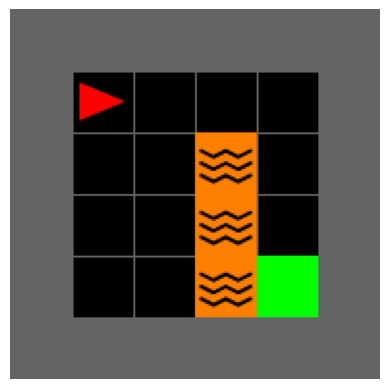

In [4]:
obs = lavagrid.render()
plt.imshow(obs)
plt.axis('off')

(-0.5, 191.5, 191.5, -0.5)

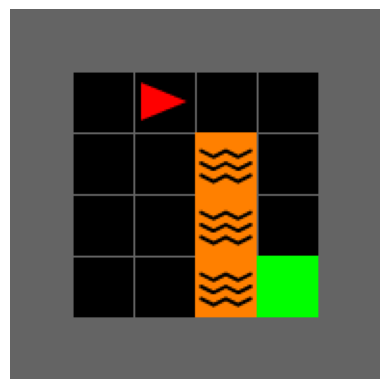

In [5]:
lavagrid.step(2)
obs = lavagrid.render()
plt.imshow(obs)
plt.axis('off')

## Windy GridWorld

In this windy version of the lavagap environment, we add the following functionalities:
- The environment is now formulated as an SCM;
- The environment has wind that blows from various directions following a given distribution;
- At the top left corner of the map, we display the wind direction when rendering, however, this is not revealed to the agent as a hidden confounder;
- The grid world simulator now supports passively observing another behavioral agent performing in the environment by calling ``see()``;
- The standard RL setting is now formulated as interventions in ``do(action)`` method;
- You can customize both wind distribution and the behavioral policy when initializing the environment.

More specifically, with wind embeded in the environment, the agent movement is affected in the following ways:
- If moving toward the same direction as the wind, the agent will now move two grids in one step;
- If moving against the wind, the agent will not move at all;
- Turning and other actions are not affected by the wind.

By default, the wind distribution is $(.1, .1, .1, .1, .6)$, which refers to the probability that the wind will blow in the direction of ``Right``, ``Down``, ``Left``, ``Up``, and ``No Wind``, respectively.

(-0.5, 191.5, 191.5, -0.5)

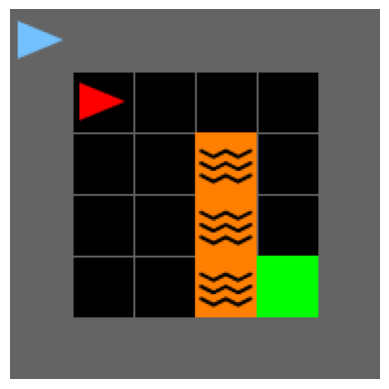

In [11]:
lavagrid = gym.make('MiniGrid-LavaGapS6-v0', max_episode_steps=30, agent_pov=False, render_mode='rgb_array', highlight=False)
windy_lavagrid = WindyMiniGrid(env=lavagrid,show_wind=True)
_, _ = windy_lavagrid.reset(seed=SEED)
obs = windy_lavagrid.render()
plt.imshow(obs)
plt.axis('off')

(-0.5, 191.5, 191.5, -0.5)

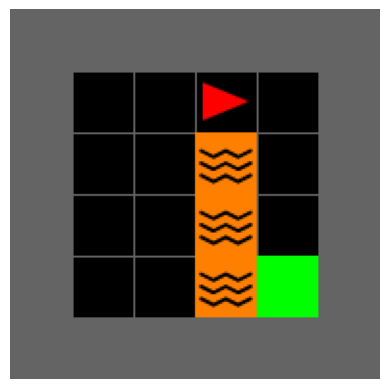

In [12]:
windy_lavagrid.do(2)
obs = windy_lavagrid.render()
plt.imshow(obs)
plt.axis('off')

(-0.5, 191.5, 191.5, -0.5)

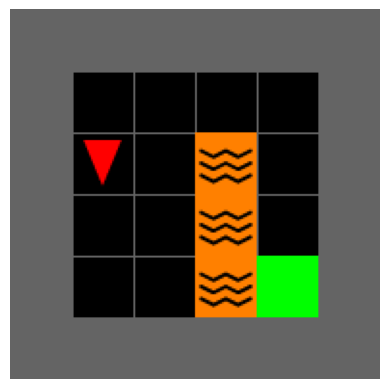

In [13]:
windy_lavagrid.reset(seed=SEED)
windy_lavagrid.do(1)
windy_lavagrid.do(2)
obs = windy_lavagrid.render()
plt.imshow(obs)
plt.axis('off')

(-0.5, 191.5, 191.5, -0.5)

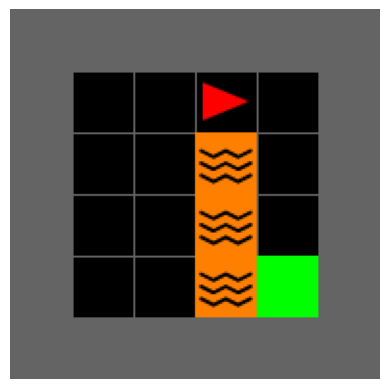

In [15]:
def behavioral_policy(*args, **kwargs):
    return 2

windy_lavagrid = WindyMiniGrid(env=lavagrid, policy=behavioral_policy, show_wind=True)
_, _ = windy_lavagrid.reset(seed=SEED)
windy_lavagrid.see()
obs = windy_lavagrid.render()
plt.imshow(obs)
plt.axis('off')

Wind direction 0: 0
Wind direction 1: 3
Wind direction 2: 4
Wind direction 3: 3


Text(0.5, 1.0, 'aft third step')

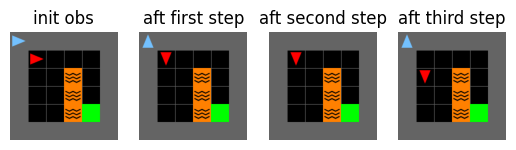

In [18]:
windy_lavagrid = WindyMiniGrid(env=lavagrid, policy=behavioral_policy, show_wind=True, wind_dist=[.2,.2,.2,.2,.2])
_, _ = windy_lavagrid.reset(seed=SEED)
print(f'Wind direction 0: {windy_lavagrid._wind_direction}')
init_obs = windy_lavagrid.render()
windy_lavagrid.do(1)
print(f'Wind direction 1: {windy_lavagrid._wind_direction}')
before_obs = windy_lavagrid.render()
windy_lavagrid.see()
print(f'Wind direction 2: {windy_lavagrid._wind_direction}')
after_obs = windy_lavagrid.render()
windy_lavagrid.see()
print(f'Wind direction 3: {windy_lavagrid._wind_direction}')
after_obs2 = windy_lavagrid.render()

fig, axes = plt.subplots(1, 4)
axes[0].imshow(init_obs)
axes[0].axis('off')
axes[0].set_title('init obs')

axes[1].imshow(before_obs)
axes[1].axis('off')
axes[1].set_title('aft first step')

axes[2].imshow(after_obs)
axes[2].axis('off')
axes[2].set_title('aft second step')

axes[3].imshow(after_obs2)
axes[3].axis('off')
axes[3].set_title('aft third step')